# Heart Failure Prediction Models

## 1. Propose well-defined questions

**Data source:** https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction

**Data Description**: According to [World Heart Report 2023](https://world-heart-federation.org/wp-content/uploads/World-Heart-Report-2023.pdf), Cardiovascular diseases (CVDs) have been the leading cause of death globally for decades, taking an estimated 17.9 million lives each year. Heart failure is a common event caused by CVDs. Individuals experiencing heart disease or those are at high heart disease risk (owing to factors such as hypertension, diabetes, high cholesterol, or existing health conditions) require early detection and intervention where machine learning models can be helpful.

**Questions**: 
- Which demographic or clinical factors have the strongest correlation with the occurrence of heart failure?
- Which is the best machine learning model to predict whether a patient is prone to heart failure depending on their demographic information, clinical attributes, and medical history?

**Dataset Detail Information**: The dataset contains 918 records, each of which has 11 features and 1 target variable.

Here's the explanation of each column:

|Column|Meaning|
|:-----:|:-----:|
|Age|age of the patient|
|Sex|gender of the patient, Male or Female|
|ChestPainType|Type of chest pain, TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic|
|RestingBP|resting blood pressure (mm Hg)|
|Cholesterol|serum cholesterol (mm/dl)|
|FastingBS|fasting blood sugar, 1 if FastingBS > 120 mg/dl, 0 otherwise |
|RestingECG|resting electrocardiogram results |
|MaxHR|maximum heart rate achieved|
|ExerciseAngina|exercise-induced angina (Y for Yes, N for No)|
|Oldpeak|[ST depression](https://www.medicalnewstoday.com/articles/st-depression-on-ecg) induced by exercise relative to rest|
|ST_Slope|the slope of the peak exercise ST segment (Up: upsloping, Flat: flat, Down: downsloping)|
|HeartDisease|1 if the patient had heart disease, 0 if not

## 2. Data preparation and exploration

### 2.1 Read data

In [1]:
# Import Packages
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as ex
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.feature_selection import RFE
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load dataset
data = pd.read_csv('heart.csv')
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
data.shape

(918, 12)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [5]:
data.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [6]:
data.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

### 2.2 Clean data

In [7]:
# Detect null values
data.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [8]:
# Drop duplicated values
data = data.drop_duplicates(subset=None, keep='first', inplace=False)
data.shape

(918, 12)

**Dataset has no null and duplicated values.**

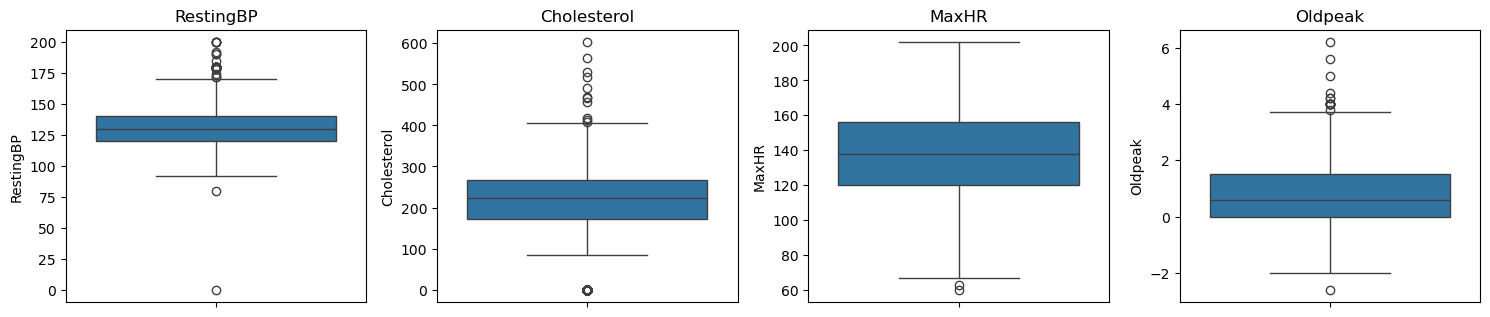

In [9]:
# Detect outlier
key_columns = ['RestingBP', 'Cholesterol','MaxHR','Oldpeak']

plt.figure(figsize = (15,12))

for i, feature in enumerate (key_columns, 1):
    plt.subplot (4,4,i)
    sns.boxplot (y = data[feature])
    plt.title (feature)
plt.tight_layout()
plt.show()


**As can be seen from above box plots, RestingBP, Cholesterol, MaxHR, Oldpeak columns have outliers.**
- The minimum and maximum values of Resting BP are 0 and 200. All data in this range are possible in reality. Thus, I do not remove outliers in this column.
- The minimum and maximum values of Cholesterol are 0 and 603. All data in this range are possible in reality. Therefore, I do not remove outliers in this column.
- The minimum and maximum values of MaxHR column are 60 and 202. All data in this range are possible in reality. Hence, we do not remove outliers in this column.  
- The minium and maximum values of Oldpeak column are -2.6 and 6.2. It means that there are some negative value in this column, which should not be true in reality. Hence, those value less than 0 will be replaced by the median of this column. 

In [10]:
# Identify negative outliers in 'Oldpeak' column
negative_oldpeak = data[data['Oldpeak'] < 0]

# Replace negative outliers with median value of this column
median_oldpeak = data['Oldpeak'].median()
data.loc[data['Oldpeak'] < 0, 'Oldpeak'] = median_oldpeak

In [11]:
# Check 'Oldpeak' column
data['Oldpeak'].describe()

count    918.000000
mean       0.909804
std        1.040160
min        0.000000
25%        0.000000
50%        0.600000
75%        1.500000
max        6.200000
Name: Oldpeak, dtype: float64

### 2.3 Visualize data

#### a. Visualize distribution of numerical columns in the dataset

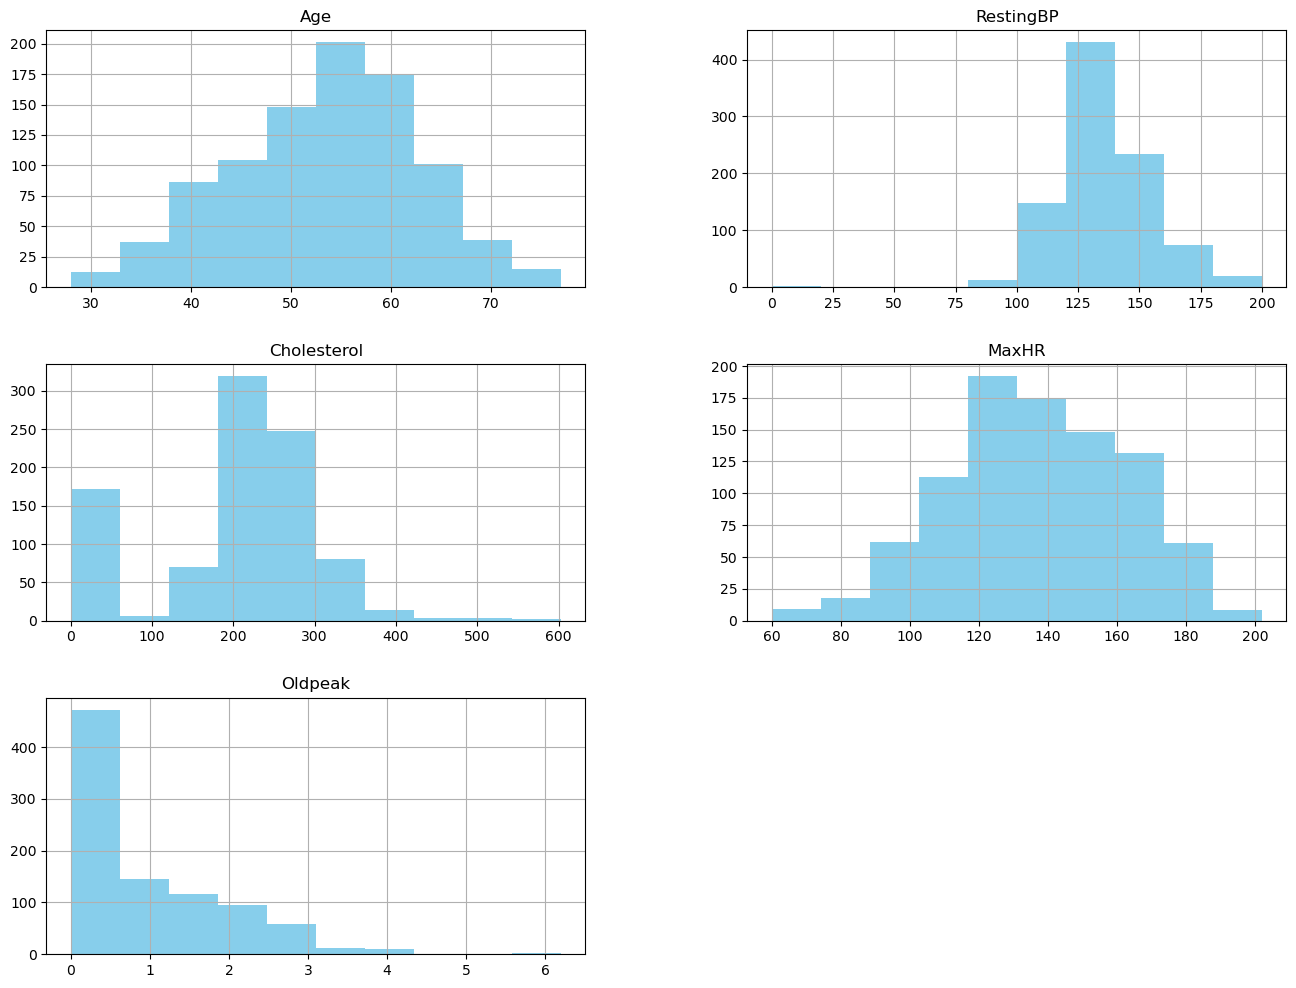

In [12]:
# Histogram of numerical columns in the dataset
numerical_columns = data[['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']]
numerical_columns.hist(bins=10 ,figsize=(16,12), color = 'skyblue')
plt.show()

**Age, RestingBP, MaxHR columns are nearly normal distributed, whereas Cholesterol column is bidmodal distributed and Oldpeak column is right skewed.**

#### b. Visualize target variable: Heart Disease Column

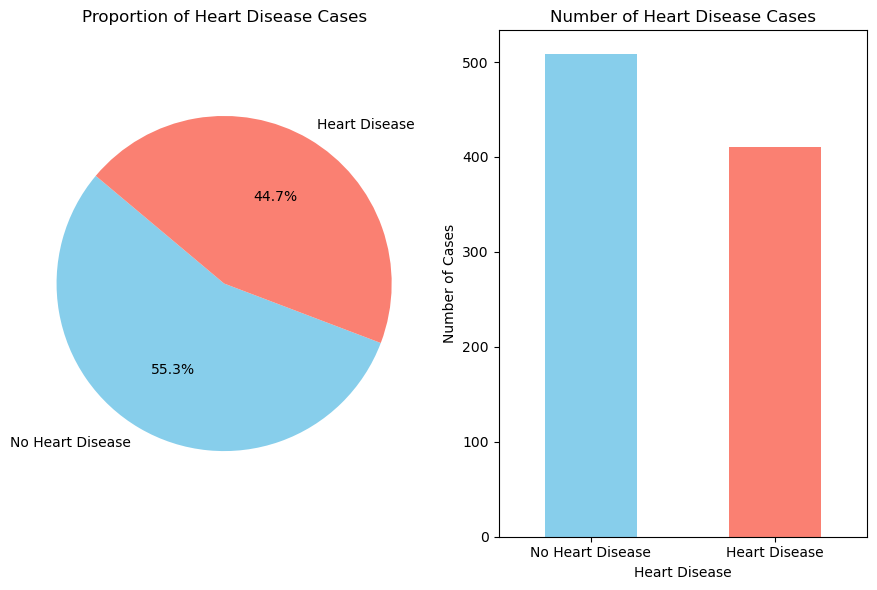

In [13]:
# Count value in Heart Disease column
heart_disease_counts = data['HeartDisease'].value_counts()

# Plot the pie chart
plt.figure(figsize=(9, 6))
plt.subplot(1, 2, 1) 
plt.pie(heart_disease_counts, labels=['No Heart Disease', 'Heart Disease'], autopct='%1.1f%%', colors=['skyblue', 'salmon'], startangle=140)
plt.title('Proportion of Heart Disease Cases')
plt.axis('equal')  

# Plot the bar chart
plt.subplot(1, 2, 2)
heart_disease_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Number of Heart Disease Cases')
plt.xlabel('Heart Disease')
plt.ylabel('Number of Cases')
plt.xticks([0, 1], ['No Heart Disease', 'Heart Disease'], rotation=0)
plt.tight_layout()
plt.show()

**As can be seen from two above charts, the proportion of Heart Disease case and No Heart Disease case in total are nearly equal, 44.7% and 55.3% respectively. Hence, the dataset is evenly balanced.**

#### c. Visualize categorical columns with target variable: Heart Disease Column

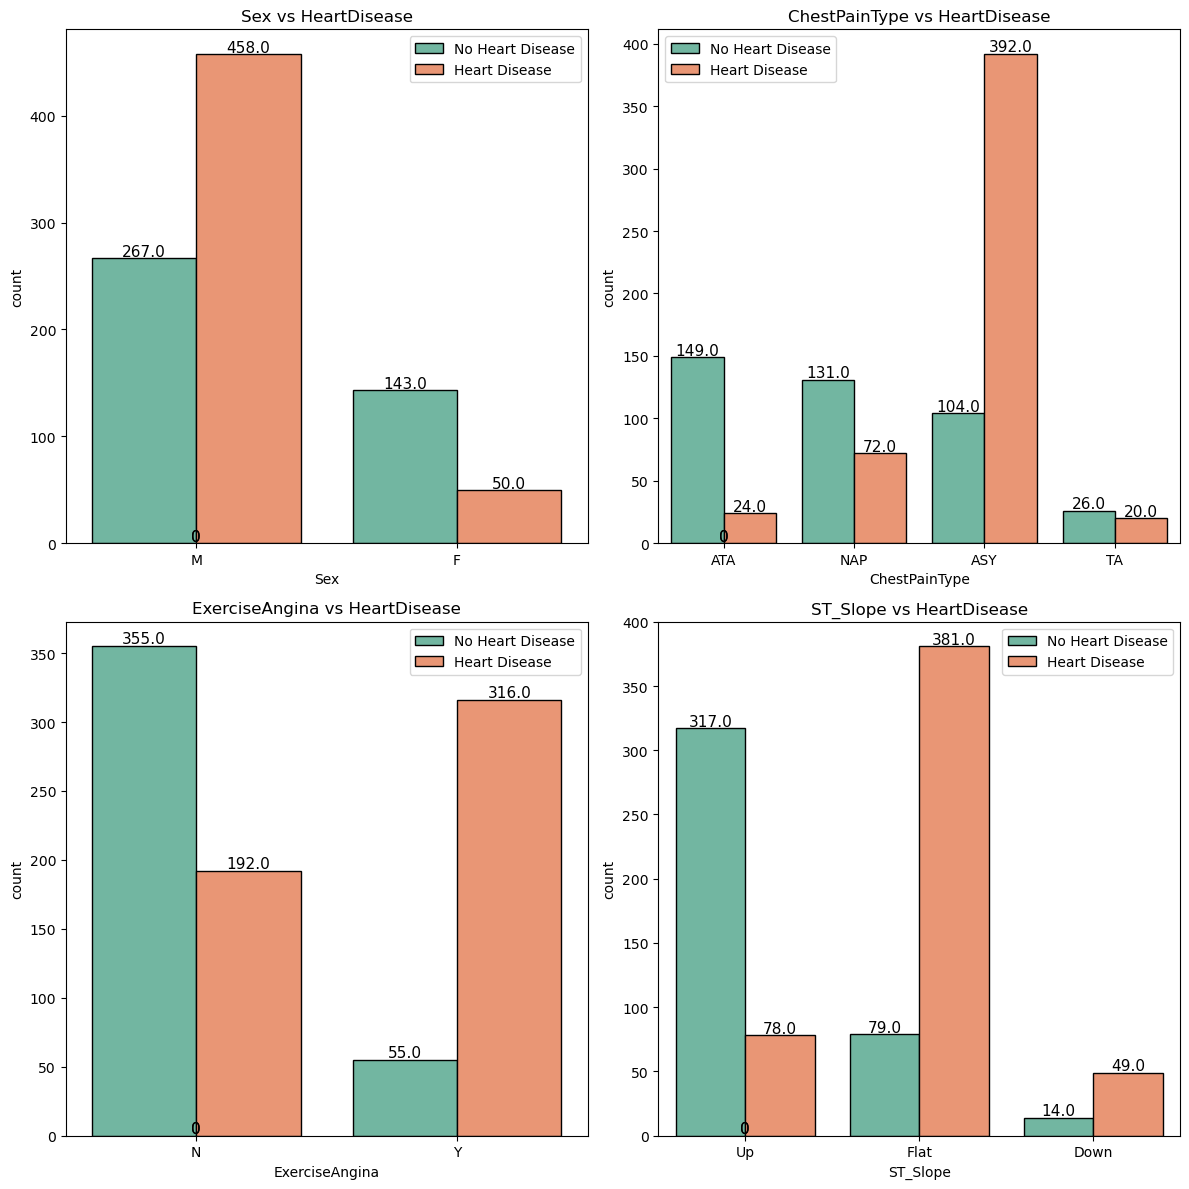

In [14]:
# Visualize categorical columns with target variable
feature = ['Sex', 'ChestPainType', 'ExerciseAngina', 'ST_Slope']

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))

for i in range(len(feature)):
    row = i // 2
    col = i % 2
    sns.countplot(x=feature[i], hue="HeartDisease", data=data, palette='Set2', edgecolor='black', ax=ax[row, col])
    for rect in ax[row, col].patches:
        ax[row, col].text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 2, rect.get_height(), 
                          horizontalalignment='center', fontsize=11)
    ax[row, col].legend(['No Heart Disease', 'Heart Disease'])
    ax[row, col].set_title(feature[i] + ' vs HeartDisease')
plt.tight_layout()
plt.show()

**There are four main points from these above bar charts:** 
- **Male population** exhibits a higher prevalence of individuals with heart disease compared to those without, whereas, in the case of **female population**, there are fewer individuals with heart disease than those without it.
- People with **chest pain type ASY** are likely to get heart disease.
- Individuals experiencing **exercise-induced angina** are at a higher risk of being diagnosed with heart disease compared to those who do not have this symptom.
- People with **Flat slope** has high probability of being diagnosed with heart disease. The **Down slope** also exhibits similar results but with a limited number of data points.

#### d. Visualize numerical columns with target variable: Heart Disease Column

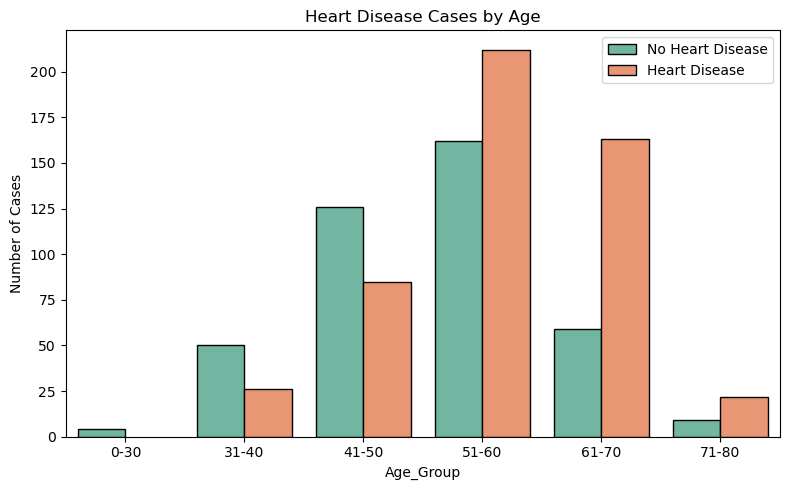

In [15]:
# Define age groups
age_bins = [0, 30, 40, 50, 60, 70, 80]
age_labels = ['0-30', '31-40', '41-50', '51-60', '61-70', '71-80']

# Create 'Age Group' column
data['Age_Group'] = pd.cut(data['Age'], bins=age_bins, labels=age_labels, right=False)

# Plotting the categorized data
plt.figure(figsize=(8, 5))
sns.countplot(x='Age_Group', hue='HeartDisease', data=data, palette='Set2', edgecolor='black')
plt.title('Heart Disease Cases by Age')
plt.xlabel('Age_Group')
plt.ylabel('Number of Cases')
plt.legend(['No Heart Disease', 'Heart Disease'])  
plt.tight_layout()
plt.show()

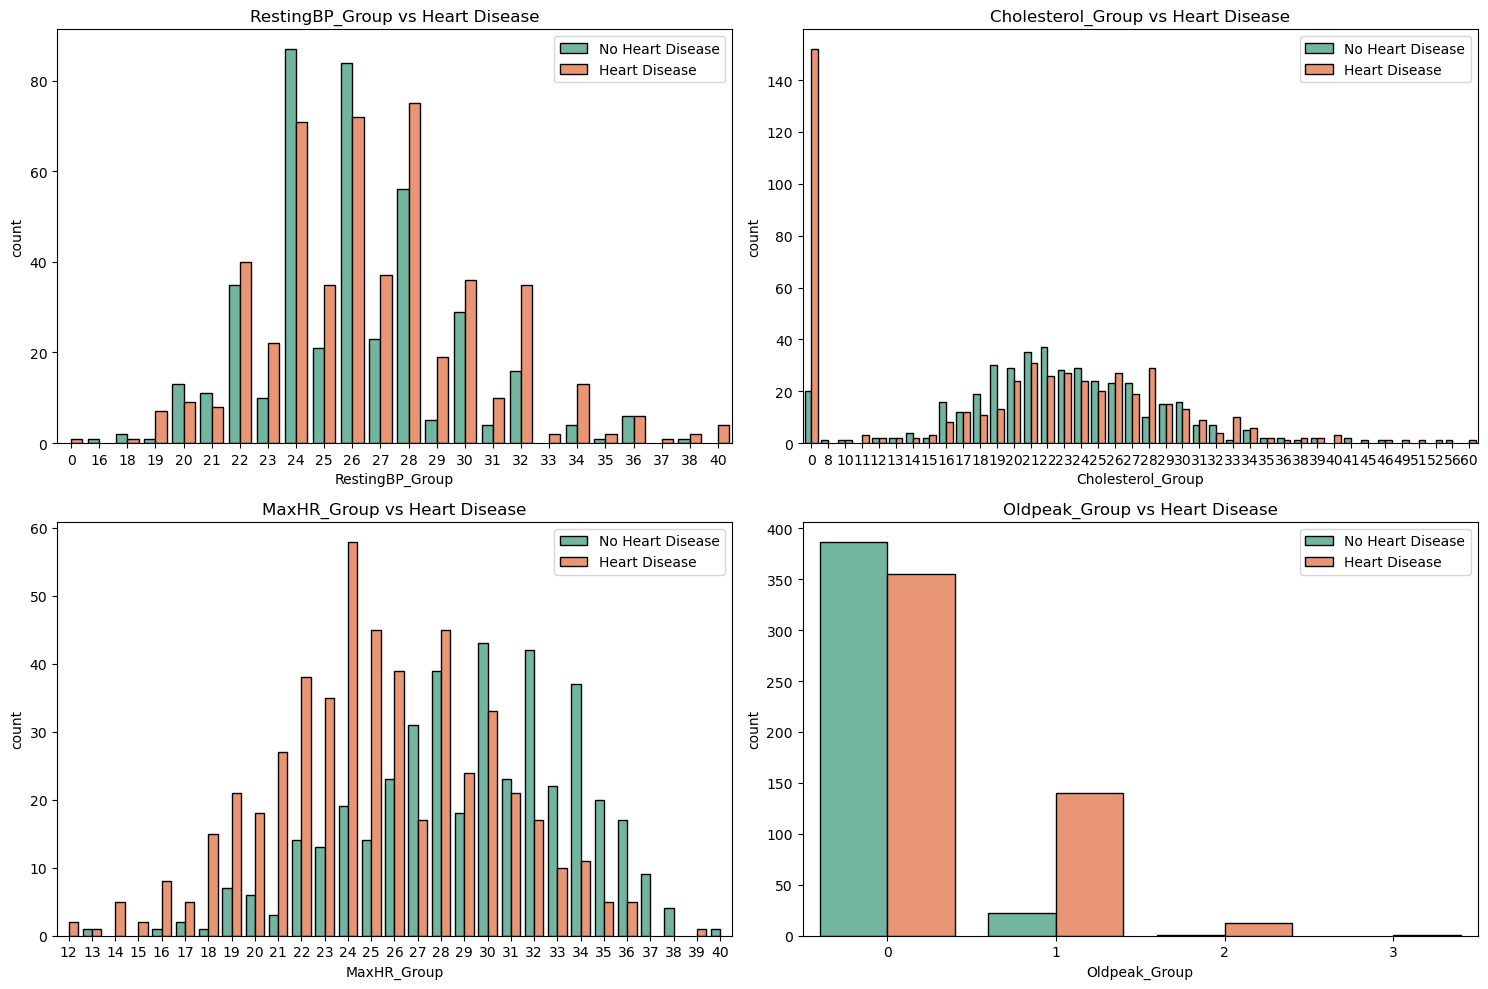

In [16]:
# Visualize other numerical columns with target variable

data['RestingBP_Group'] = [ int(i / 5) for i in data['RestingBP']]
data['Cholesterol_Group'] = [ int(i / 10) for i in data['Cholesterol']]
data['MaxHR_Group'] = [ int(i / 5) for i in data['MaxHR']]
data['Oldpeak_Group'] = [ int(i/2) for i in data['Oldpeak']]

numerical_features = data[['RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']]
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
group_numerical_features = [i + '_Group' for i in numerical_features.columns]

for i in range(2):
    for j in range(2):
        sns.countplot(x=group_numerical_features[i*2 + j], data=data, hue="HeartDisease", palette='Set2', edgecolor='black', ax=ax[i][j])
        ax[i][j].legend(['No Heart Disease', 'Heart Disease'])
        title = group_numerical_features[i*2 + j] + ' vs Heart Disease'
        ax[i][j].set_title(title)

plt.tight_layout()
plt.show()

**There are five main points from five above bar charts:**
- Individuals in the **age group from 51 to 60** have higher chance of being diagnosed with heart disease than other age group. 
- In the **RestingBP** group data, individuals in the range **110 (22x5)- 160 (32x5)** are most prone to be dectected with heart diseases. 
- People with **cholesterol levels** between **160 (16x10) - 340 (34x10)** are highly susceptible to heart diseases.
- Heart diseases are evident across **the MaxHR**, with a significant number of cases detected between **70 (14x5) and 180 (36x5)** values. 
- Similarly, the **Oldpeak values** consistently indicate the presence of heart diseases. Slope values ranging from **0 (0/2) to 0.5 (1/2)** exhibit a high likelihood of heart disease diagnosis.

### 2.4 Study correlation between features and target variable

In [17]:
# Check data
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,Age_Group,RestingBP_Group,Cholesterol_Group,MaxHR_Group,Oldpeak_Group
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0,41-50,28,28,34,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1,41-50,32,18,31,0
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0,31-40,26,28,19,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1,41-50,27,21,21,0
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0,51-60,30,19,24,0


In [18]:
# Change categorical data to numerical data
from sklearn.preprocessing import OrdinalEncoder

ord_enc = OrdinalEncoder()
data["Sex_code"] = ord_enc.fit_transform(data[["Sex"]])
data["ChestPainType_code"] = ord_enc.fit_transform(data[["ChestPainType"]])
data["RestingECG_code"] = ord_enc.fit_transform(data[["RestingECG"]])
data["ExerciseAngina_code"] = ord_enc.fit_transform(data[["ExerciseAngina"]])
data["ST_Slope_code"] = ord_enc.fit_transform(data[["ST_Slope"]])

In [19]:
# Drop unnecessary columns from dataset
data = data.drop(['Sex','ChestPainType','RestingECG','ExerciseAngina','ST_Slope','Age_Group','RestingBP_Group','Cholesterol_Group','MaxHR_Group','Oldpeak_Group'],axis = 1)
data.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_code,ChestPainType_code,RestingECG_code,ExerciseAngina_code,ST_Slope_code
0,40,140,289,0,172,0.0,0,1.0,1.0,1.0,0.0,2.0
1,49,160,180,0,156,1.0,1,0.0,2.0,1.0,0.0,1.0
2,37,130,283,0,98,0.0,0,1.0,1.0,2.0,0.0,2.0
3,48,138,214,0,108,1.5,1,0.0,0.0,1.0,1.0,1.0
4,54,150,195,0,122,0.0,0,1.0,2.0,1.0,0.0,2.0


In [20]:
# Study correlation among attributes
data.corr()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_code,ChestPainType_code,RestingECG_code,ExerciseAngina_code,ST_Slope_code
Age,1.000000,0.254399,-0.095282,0.198039,-0.382045,0.261496,0.282039,0.055750,-0.077150,-0.007484,0.215793,-0.268264
RestingBP,0.254399,1.000000,0.100893,0.070193,-0.112135,0.145925,0.107589,0.005133,-0.020647,0.022656,0.155101,-0.075162
Cholesterol,-0.095282,0.100893,1.000000,-0.260974,0.235792,0.013250,-0.232741,-0.200092,0.067880,-0.196544,-0.034166,0.111471
FastingBS,0.198039,0.070193,-0.260974,1.000000,-0.131438,0.078813,0.267291,0.120076,-0.073151,0.087050,0.060451,-0.175774
MaxHR,-0.382045,-0.112135,0.235792,-0.131438,1.000000,-0.176571,-0.400421,-0.189186,0.289123,-0.179276,-0.370425,0.343419
Oldpeak,0.261496,0.145925,0.013250,0.078813,-0.176571,1.000000,0.424747,0.119555,-0.180006,-0.009298,0.411604,-0.521660
HeartDisease,0.282039,0.107589,-0.232741,0.267291,-0.400421,0.424747,1.000000,0.305445,-0.386828,0.057384,0.494282,-0.558771
Sex_code,0.055750,0.005133,-0.200092,0.120076,-0.189186,0.119555,0.305445,1.000000,-0.126559,0.071552,0.190664,-0.150693
ChestPainType_code,-0.077150,-0.020647,0.067880,-0.073151,0.289123,-0.180006,-0.386828,-0.126559,1.000000,-0.072537,-0.354727,0.213521
RestingECG_code,-0.007484,0.022656,-0.196544,0.087050,-0.179276,-0.009298,0.057384,0.071552,-0.072537,1.000000,0.077500,-0.006778


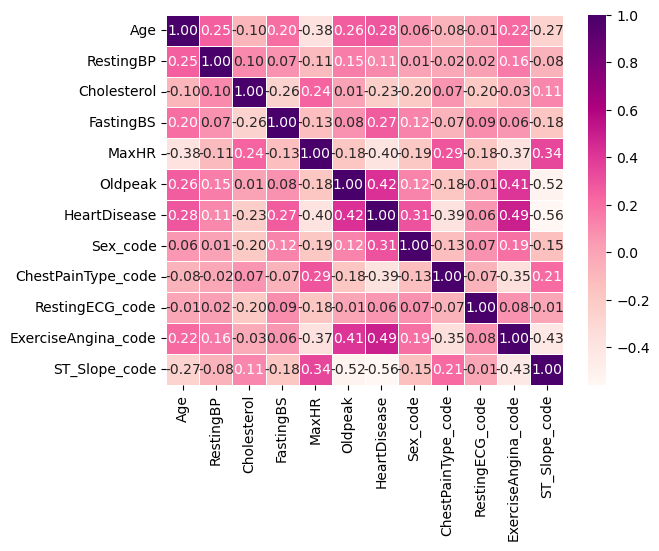

In [21]:
# Plotting the heatmap for better visualization
correlation = data.corr()
sns.heatmap(correlation, annot=True, linewidth=0.5, cmap="RdPu", fmt = ".2f")
plt.show()

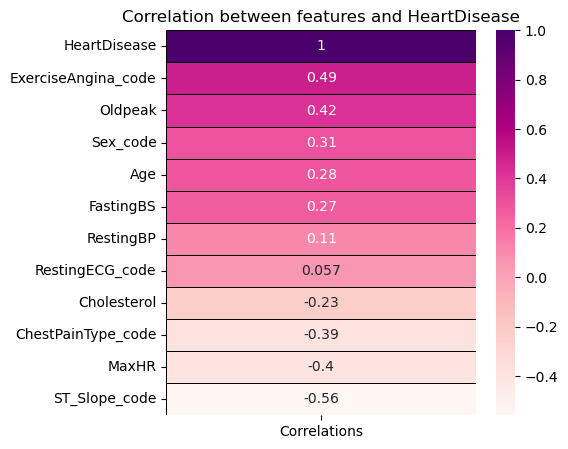

In [22]:
# Correlation between features and HeartDisease
corr = data.corrwith(data['HeartDisease']).sort_values(ascending=False).to_frame()
corr.columns = ['Correlations']

plt.subplots(figsize=(5, 5))
sns.heatmap(corr, annot=True, cmap='RdPu', linewidths=0.4, linecolor='black')
plt.title('Correlation between features and HeartDisease')
plt.show()

**Find 5 most correlated features with Heart Disease**
- 5 most features that are most correlated to Heart Disease are 'ST_Slope_code','ExerciseAngina_code', 'Oldpeak', 'MaxHR','Sex_code'. 

**Answer Question 1: Which demographic or clinical factors have the strongest correlation with the occurrence of heart failure?**
- The most correlated feature with Heart Disease is ST_Slope_code, with a correlation coefficient of -0.56. This indicates a moderately negative correlation, meaning that as the value of ST_Slope_code increases, the likelihood of heart disease decreases. In other words, individuals with certain values of ST_Slope_code are more likely to have heart disease compared to other factors. 

## 3. Prediction Techniques

### Name of four models
- Model 1: Logistic Regression Model with 5 most correlated features
- Model 2: Logistic Regression Model with Feature Selection (4 features)
- Model 3: KNN Model with random K
- Model 4: KNN Model with best K value (GridSearchCV)

### 3.1 Model 1: Logistic Regression Model with 5 most correlated features

5 most features that are most correlated to Heart Disease are **'ExerciseAngina_code', 'Oldpeak', 'Sex_code', 'Age', and 'FastingBS'.**

In [23]:
# Determine X,y for training and testing data
X = data [['ST_Slope_code','ExerciseAngina_code', 'Oldpeak', 'MaxHR','Sex_code']]
y = data['HeartDisease']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=200)

print("X_train shape: {}".format(X_train.shape))
print("y_train shape: {}".format(y_train.shape))
print("X_test shape: {}".format(X_test.shape))
print("y_test shape: {}".format(y_test.shape))

X_train shape: (734, 5)
y_train shape: (734,)
X_test shape: (184, 5)
y_test shape: (184,)


In [24]:
# Training Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [25]:
# Doing predictions on train and test set
y_hat_train = model.predict(X_train)
y_hat_test = model.predict(X_test)

In [26]:
# Evaluate the performance of trained model

#Calculate Accuracy score
print("Accuracy score on testing data: ", accuracy_score(y_test, y_hat_test))
model1_acc = accuracy_score(y_test, y_hat_test)

# Calculate F1-score
print("F1-score on testing data: ", f1_score(y_test, y_hat_test))
model1_f1 = f1_score(y_test, y_hat_test)

# Calculate AUC
y_pred_prob_test = model.predict_proba(X_test)[:, 1]
print("AUC-ROC on testing set: ", roc_auc_score(y_test, y_pred_prob_test))
model1_auc = roc_auc_score(y_test, y_pred_prob_test)

Accuracy score on testing data:  0.8641304347826086
F1-score on testing data:  0.8858447488584474
AUC-ROC on testing set:  0.9038461538461537


In [27]:
# Use k-fold cross validation for testing accuracy estimation
model = LogisticRegression()
scores = cross_val_score(model, X, y, cv=10)

# Calculate the mean accuracy score
model1_cv = scores.mean()
model1_cv

0.8331820353559485

### 3.2 Model 2: Logistic Regression Model with Feature Selection

In [28]:
# Determine X,y for training and testing data
X = data.drop(['HeartDisease'],axis=1)
y = data['HeartDisease']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=200)

In [29]:
# Estimate accuracy score on test set using RFE
acc_scores = []
for i in range(1,12):
    clf = LogisticRegression()
    rfe = RFE(estimator=clf, n_features_to_select=i)
    # training model
    rfe.fit(X_train, y_train)
    # predicting on test set
    y_pred = rfe.predict(X_test)
    acc_score = accuracy_score(y_test, y_pred)
    # print this
    print("Acc on test set using", i, "features: ", acc_score)
    # append to the list
    acc_scores.append(acc_score)

Acc on test set using 1 features:  0.8206521739130435
Acc on test set using 2 features:  0.8369565217391305
Acc on test set using 3 features:  0.8260869565217391
Acc on test set using 4 features:  0.8586956521739131
Acc on test set using 5 features:  0.8260869565217391
Acc on test set using 6 features:  0.842391304347826
Acc on test set using 7 features:  0.8315217391304348
Acc on test set using 8 features:  0.7989130434782609
Acc on test set using 9 features:  0.7989130434782609
Acc on test set using 10 features:  0.8315217391304348
Acc on test set using 11 features:  0.8260869565217391


**Model with 4 features have highest accuracy score.**

In [30]:
# Creating RFE object
lr_model = LogisticRegression()
rfe = RFE(estimator=lr_model, n_features_to_select=4, step=1)
rfe.fit(X_train, y_train)

RFE(estimator=LogisticRegression(), n_features_to_select=4)

In [31]:
# Do evaluation on test set
y_hat_test = rfe.predict(X_test)
print("Accuracy score on test set: ", accuracy_score(y_test, y_hat_test))

Accuracy score on test set:  0.8586956521739131


In [32]:
# Summarize all features
for i in range(X_train.shape[1]):
    print('Column: %d, Selected %s, Rank: %.3f' % (i, rfe.support_[i], rfe.ranking_[i]))

Column: 0, Selected False, Rank: 5.000
Column: 1, Selected False, Rank: 6.000
Column: 2, Selected False, Rank: 7.000
Column: 3, Selected True, Rank: 1.000
Column: 4, Selected False, Rank: 8.000
Column: 5, Selected False, Rank: 3.000
Column: 6, Selected True, Rank: 1.000
Column: 7, Selected False, Rank: 2.000
Column: 8, Selected False, Rank: 4.000
Column: 9, Selected True, Rank: 1.000
Column: 10, Selected True, Rank: 1.000


In [33]:
X_train

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_code,ChestPainType_code,RestingECG_code,ExerciseAngina_code,ST_Slope_code
269,47,130,235,0,145,2.0,0.0,2.0,1.0,0.0,1.0
316,57,105,0,1,148,0.3,1.0,2.0,1.0,0.0,1.0
436,58,116,0,0,124,1.0,1.0,0.0,1.0,0.0,2.0
344,51,120,0,1,104,0.0,1.0,0.0,1.0,0.0,1.0
240,55,145,326,0,155,0.0,1.0,1.0,1.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...
810,55,135,250,0,161,1.4,0.0,1.0,0.0,0.0,1.0
836,65,135,254,0,127,2.8,1.0,0.0,0.0,0.0,1.0
784,65,138,282,1,174,1.4,1.0,3.0,0.0,0.0,1.0
617,57,124,261,0,141,0.3,1.0,1.0,1.0,0.0,2.0


From the result above, 4 columns **'FastingBS', 'Sex_code', 'ExerciseAngina_code', 'ST_Slope_code'** will be used for building model. 

In [34]:
# Determine features for training and testing data
X_train_lr = X_train[['FastingBS','Sex_code','ExerciseAngina_code','ST_Slope_code']]
X_test_lr = X_test[['FastingBS','Sex_code','ExerciseAngina_code','ST_Slope_code']]

In [35]:
# Build Logistic Regression model
lr_2 = LogisticRegression()
lr_2.fit(X_train_lr, y_train)
# Do predictions
y_pred_lr = lr_2.predict(X_test_lr)

# Creating RFE object
rfe1 = RFE(estimator= lr_2, n_features_to_select=4, step=1)
rfe1.fit(X_train_lr, y_train)

RFE(estimator=LogisticRegression(), n_features_to_select=4)

In [36]:
# Evaluate model

# Calculate Accuracy score
print('Accuracy score on testing data: ',accuracy_score(y_test, y_pred_lr))
model2_acc = accuracy_score(y_test, y_pred_lr)

# Calculate F1-score
print("F1-score on testing data: ", f1_score(y_test, y_pred_lr))
model2_f1 = f1_score(y_test, y_pred_lr)

# Calculate AUC
y_pred_prob_test = lr_2.predict_proba(X_test_lr)[:, 1]
print("AUC-ROC on testing set: ", roc_auc_score(y_test, y_pred_prob_test))
model2_auc = roc_auc_score(y_test, y_pred_prob_test)

Accuracy score on testing data:  0.8586956521739131
F1-score on testing data:  0.8839285714285714
AUC-ROC on testing set:  0.8867924528301887


In [37]:
# Use k-fold cross validation for testing accuracy estimation
model = LogisticRegression()
scores = cross_val_score(model, X, y, cv=10)
# Calculate the mean accuracy score
model2_cv = scores.mean()
model2_cv

0.8354395604395604

### 3.3 Model 3: KNN Model with random K

In [38]:
# Determine X,y for training and testing data
X = data.drop(['HeartDisease'],axis=1)
y = data['HeartDisease']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=200)

# Create and training a KNN classifier model with k = 10
clf = KNeighborsClassifier(n_neighbors = 10)
clf.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=10)

In [39]:
# Use the model to predict testing data and calculate Accuracy score
y_pred = clf.predict(X_test)
model3_acc = accuracy_score(y_test,y_pred)
print('Accuracy score of KNN: ', model3_acc)

# Calculate F1-score
print("F1-score on testing set: ", f1_score(y_test, y_pred))
model3_f1 = f1_score(y_test, y_pred)

# Calculate AUC
y_pred_prob_test = clf.predict_proba(X_test)[:, 1]
print("AUC-ROC on testing set: ", roc_auc_score(y_test, y_pred_prob_test))
model3_auc = roc_auc_score(y_test, y_pred_prob_test)

Accuracy score of KNN:  0.7391304347826086
F1-score on testing set:  0.7669902912621359
AUC-ROC on testing set:  0.8386550556361877


In [40]:
# Create a KNN classifier model and use k-fold cross validation for testing accuracy estimation
clf = KNeighborsClassifier(n_neighbors = 10)
scores = cross_val_score(clf, X, y, cv=10)
print('Accuracy for each round: \n', scores)
print('Average accuracy: %.4f +- %.4f' % (scores.mean(), scores.std()))
model3_cv = scores.mean()

Accuracy for each round: 
 [0.65217391 0.60869565 0.84782609 0.89130435 0.70652174 0.60869565
 0.77173913 0.60869565 0.61538462 0.67032967]
Average accuracy: 0.6981 +- 0.0995


### 3.4 Model 4: Build KNN Model with best K value (GridSearchCV)

In [41]:
X = data.drop(['HeartDisease'],axis=1)
y = data['HeartDisease']

# Data split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=200)

# Define search space for parameters
parameter_grid = {'n_neighbors': range(1, 135, 5)}

# Create the machine learning model
knn_clf = KNeighborsClassifier()
clf = GridSearchCV(knn_clf, parameter_grid, scoring='roc_auc', cv=10)
clf.fit(X_train, y_train)

# Identify the best parameter(s)
print('Best K value: ', clf.best_params_['n_neighbors'])
print('The AUC: ', clf.best_score_)

Best K value:  51
The AUC:  0.7576173590278683


In [42]:
# Create and training a KNN classifier model with K = 51
clf = KNeighborsClassifier(n_neighbors = 51)
clf.fit(X_train, y_train)

# Use the model to predict testing data and calculate Accuracy score
y_pred = clf.predict(X_test)
model4_acc = accuracy_score(y_test,y_pred)
print('Accuracy score of KNN: ', model4_acc)

# Calculate F1-score
print("F1-score on testing set: ", f1_score(y_test, y_pred))
model4_f1 = f1_score(y_test, y_pred)

# Calculate AUC
y_pred_prob_test = clf.predict_proba(X_test)[:, 1]
print("AUC-ROC on testing set: ", roc_auc_score(y_test, y_pred_prob_test))
model4_auc = roc_auc_score(y_test, y_pred_prob_test)

Accuracy score of KNN:  0.7608695652173914
F1-score on testing set:  0.7924528301886793
AUC-ROC on testing set:  0.8537735849056605


In [43]:
# Create a KNN classifier model and use k-fold cross validation for testing accuracy estimation
clf = KNeighborsClassifier(n_neighbors = 51)
scores = cross_val_score(clf, X, y, cv=10)
print('Accuracy for each round: \n', scores)
print('Average accuracy: %.4f +- %.4f' % (scores.mean(), scores.std()))
model4_cv = scores.mean()

Accuracy for each round: 
 [0.63043478 0.64130435 0.7826087  0.82608696 0.73913043 0.66304348
 0.7826087  0.70652174 0.61538462 0.62637363]
Average accuracy: 0.7013 +- 0.0730


## 4.  Visualization and Analysis of model performance evaluation results

### 4.1 Name of four models
- Model 1: Logistic Regression Model with 5 most correlated features
- Model 2: Logistic Regression Model with Feature Selection (4 features)
- Model 3: KNN Model with random K
- Model 4: KNN Model with best K value (GridSearchCV)

### 4.2 Summarize metrics for evaluating 4 models

In [44]:
df = pd.DataFrame({
    'Accuracy score': [model1_acc, model2_acc, model3_acc, model4_acc],
    'F1 score': [model1_f1, model2_f1, model3_f1, model4_f1],
    'AUC': [model1_auc, model2_auc, model3_auc, model4_auc],
    'Accuracy score with Cross-Validation': [model1_cv, model2_cv, model3_cv, model4_cv]},
     index=['Model 1', 'Model 2', 'Model 3', 'Model 4'])
df

,Accuracy score,F1 score,AUC,Accuracy score with Cross-Validation
Model 1,0.864130,0.885845,0.903846,0.833182
Model 2,0.858696,0.883929,0.886792,0.835440
Model 3,0.739130,0.766990,0.838655,0.698137
Model 4,0.760870,0.792453,0.853774,0.701350


### 4.3 Visualize metrics for evaluating 4 models

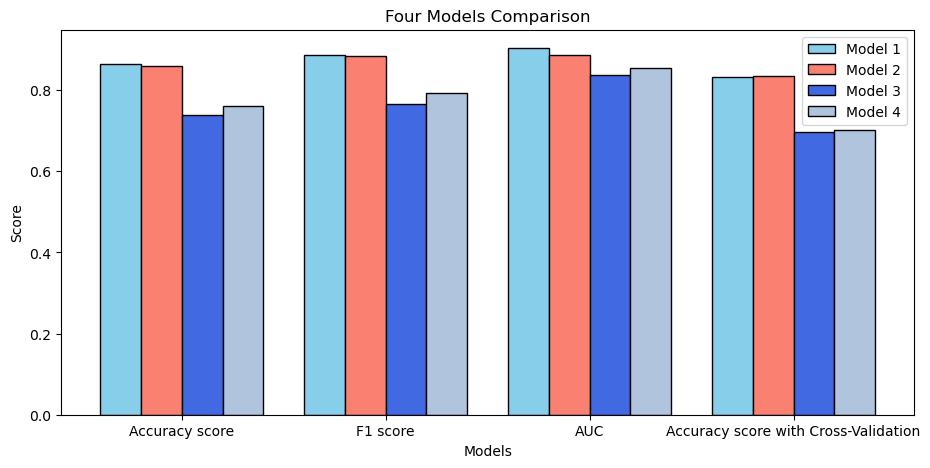

In [45]:
plt.figure(figsize=(11,5))

# Set the x-axis labels
labels = ['Accuracy score','F1 score', 'AUC', 'Accuracy score with Cross-Validation']

# Set the y-axis data
model1_scores = [model1_acc, model1_f1, model1_auc, model1_cv]
model2_scores = [model2_acc, model2_f1, model2_auc, model2_cv]
model3_scores = [model3_acc, model3_f1, model3_auc, model3_cv]
model4_scores = [model4_acc, model4_f1, model4_auc, model4_cv]


# Set the bar width
bar_width = 0.2

# Set the x positions of the bars
r1 = np.arange(len(model1_scores))
r2 = [x + bar_width for x in r1]
r3 = [x + bar_width for x in r2]
r4 = [x + bar_width for x in r3]

# Create the bar plot
plt.bar(r1, model1_scores, color='skyblue', width=bar_width, edgecolor='black', label='Model 1')
plt.bar(r2, model2_scores, color='salmon', width=bar_width, edgecolor='black', label='Model 2')
plt.bar(r3, model3_scores, color='royalblue', width=bar_width, edgecolor='black', label='Model 3')
plt.bar(r4, model4_scores, color='lightsteelblue', width=bar_width, edgecolor='black', label='Model 4')


# Add labels and titles
plt.xticks([r + bar_width *1.5 for r in range(len(model1_scores))], labels)
plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Four Models Comparison')
plt.legend()
plt.show()

### 4.4 Analysis of model performance evaluation results

**Accuracy score** measures the proportion of correct predictions among the total number of predictions made by the model, ranging from 0 to 1. 
- Model 1 has the highest accuracy score at 0.8641, indicating that it correctly predicts the outcome for approximately 86.4% of instances. This makes it the most accurate model in terms of predicting the correct outcome.
- Model 2 follows closely with an accuracy score of 0.8587, predicting about 85.9% of instances correctly, though slightly lower than Model 1.
- Model 4 has an accuracy of 0.7609, performing better than Model 3.
- Model 3 shows the lowest accuracy at 0.7391, indicating it struggles to make correct predictions compared to the other models.

**F1-score** is the model’s balanced ability to both capture positive cases (recall) and be accurate with the cases it does capture (precision), ranging from 0 to 1. 
- Model 1 has the highest F1 score at 0.8858, reflecting its excellent ability to balance precision and recall, making it the most effective at identifying positive cases without sacrificing accuracy.
- Model 2 is slightly behind with an F1 score of 0.8839, indicating a similarly strong balance, though slightly less than Model 1.
- Model 4 scores 0.7925, and Model 3 has a lower F1 score of 0.7670, indicating that both models struggle more with balancing precision and recall compared to Models 1 and 2.

**AUC (Area under the ROC Curve)** measures the ability of the model to distinguish between classes. 
- Model 1 leads with an AUC of 0.9038, demonstrating its superior ability to differentiate between positive and negative cases. This makes it the best model for separating the two classes.
- Model 2 follows with an AUC of 0.8868, which is still strong but not as high as Model 1.
- Model 4 has an AUC of 0.8538, while Model 3 shows the lowest AUC at 0.8387, indicating these models are less effective at distinguishing between classes.

**Accuracy score with Cross-Validation** measures the model's stability and reliability by averaging performance across 10 folds 
- Model 1 remains highly consistent, with a cross-validated accuracy score of 0.8332, demonstrating strong generalization across different subsets of data.
- Model 2 slightly outperforms Model 1 in this metric with 0.8354, but the difference is minimal.
- Model 4 and Model 3 have lower cross-validated accuracies at 0.7014 and 0.6981, respectively, indicating they generalize less effectively and are more prone to misclassification.

In conclusion, **Model 1 consistently performs the best across  three metrics**, indicating its superior predictive ability and robustness. Models 2 and 4 show moderate performance, whereas Model 3 demonstrates the weakest performance among the models evaluated.

**Answer Question 2: Which is the best machine learning model to predict whether a patient is prone to heart failure depending on their demographic information, clinical attributes, and medical history?**

**Logistic Regression Model with 5 most correlated features** is the best model to predict whether a patient is prone to heart failure depending on their demographic information, clinical attributes, and medical history. 

## 5. Summarise answers for two question

**Question 1:**
ST_Slope_code has the strongest correlation with the occurrence of heart failure. 

**Question 2:**
Logistic Regression Model with 5 most correlated features is the best model to predict whether a patient is prone to heart failure depending on their demographic information, clinical attributes, and medical history. 